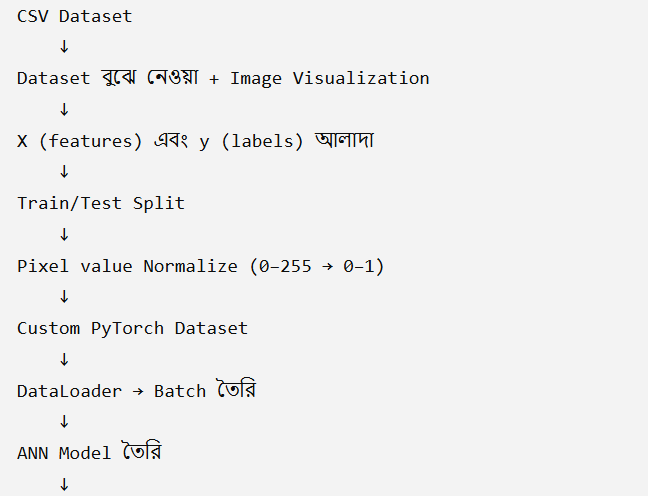

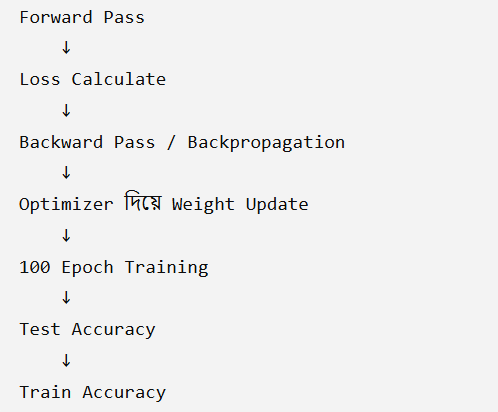

In [69]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.optim as optim

In [70]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cpu


In [71]:
df = pd.read_csv("fmnist_small.csv")
df

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,pixel10,pixel11,pixel12,pixel13,pixel14,pixel15,pixel16,pixel17,pixel18,pixel19,pixel20,pixel21,pixel22,pixel23,pixel24,pixel25,pixel26,pixel27,pixel28,pixel29,pixel30,pixel31,pixel32,pixel33,pixel34,pixel35,pixel36,pixel37,pixel38,pixel39,...,pixel745,pixel746,pixel747,pixel748,pixel749,pixel750,pixel751,pixel752,pixel753,pixel754,pixel755,pixel756,pixel757,pixel758,pixel759,pixel760,pixel761,pixel762,pixel763,pixel764,pixel765,pixel766,pixel767,pixel768,pixel769,pixel770,pixel771,pixel772,pixel773,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,9,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,125,72,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,3,0,2,0,0,210,228,228,233,0,0,0,0,0,0,0,0,0,31,81,133,184,201,190,117,0,0,2,1,0,7,0,50,205,196,213,165,0,0
1,7,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,1,0,0,0,0,43,117,34,15,24,33,117,80,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,51,144,152,...,157,158,161,148,159,58,0,6,0,0,0,0,0,0,0,0,0,4,0,60,143,143,148,146,152,152,148,148,147,145,142,142,142,21,0,3,0,0,0,0
3,8,0,0,0,0,0,0,0,0,0,0,0,0,2,0,33,114,37,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,...,11,17,13,13,11,10,7,5,5,5,7,0,0,0,1,0,0,41,69,88,86,94,106,114,118,47,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,8,0,0,0,0,0,0,0,0,0,0,2,0,58,145,114,10,0,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2,0,...,165,153,155,134,143,172,215,62,0,0,0,0,0,0,0,0,10,190,178,194,209,211,209,205,211,215,213,217,225,228,213,203,174,151,188,10,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5995,1,0,0,0,0,0,0,0,0,0,1,147,114,108,110,108,74,55,113,131,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,61,246,...,238,215,255,164,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,24,74,145,6,0,0,27,137,76,69,12,0,0,0,0,0,0,0,0
5996,5,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
5997,8,0,0,0,0,0,0,0,0,0,0,0,23,125,109,104,107,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,2,0,68,...,139,157,186,252,255,154,53,238,0,0,0,0,0,0,11,61,0,0,36,91,67,93,126,133,135,139,135,143,132,79,39,47,2,0,0,29,0,0,0,0
5998,4,0,0,0,0,0,0,0,0,0,1,0,0,140,109,118,151,58,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,...,240,243,227,70,0,235,189,188,64,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,44,70,55,33,0,0,0,0,0,0,0,0,0,0,0


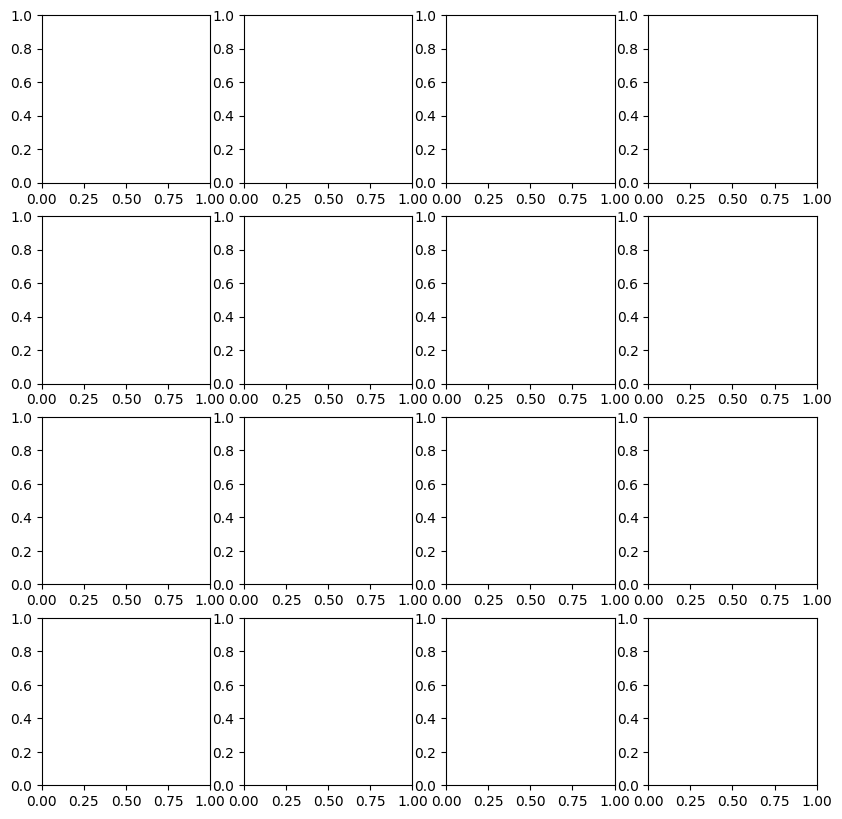

In [72]:
fig, axes = plt.subplots(4, 4, figsize=(10,10))

Text(0.5, 0.98, 'First 16 Images')

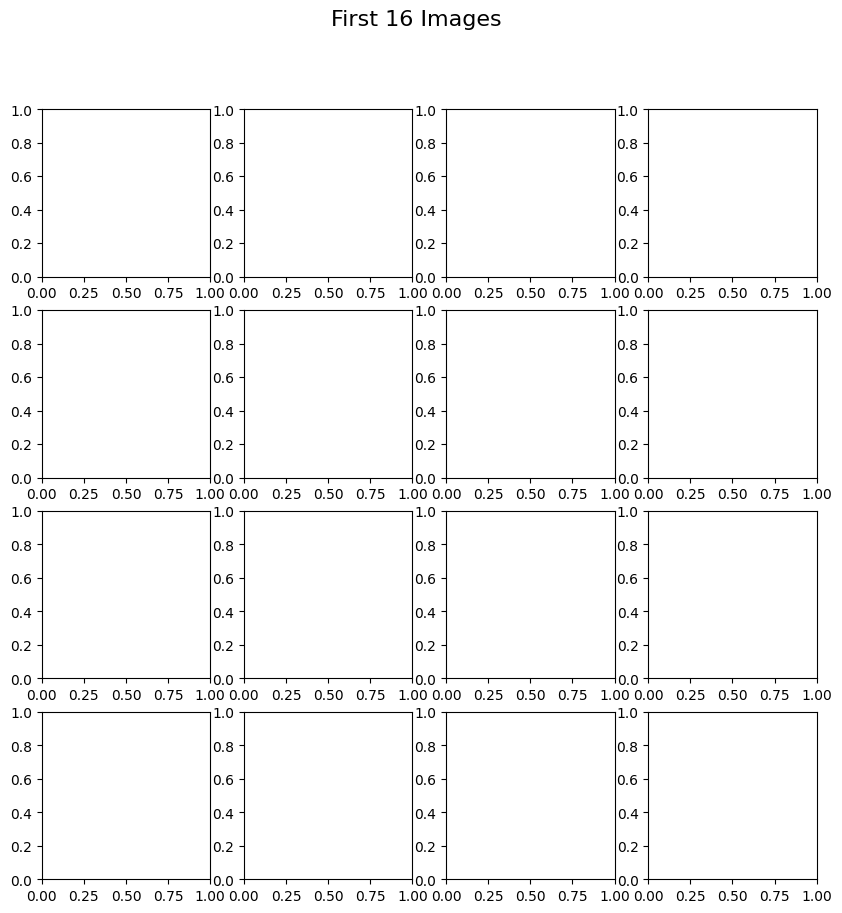

In [73]:
fig, axes = plt.subplots(4, 4, figsize=(10,10))
fig.suptitle("First 16 Images", fontsize=16)

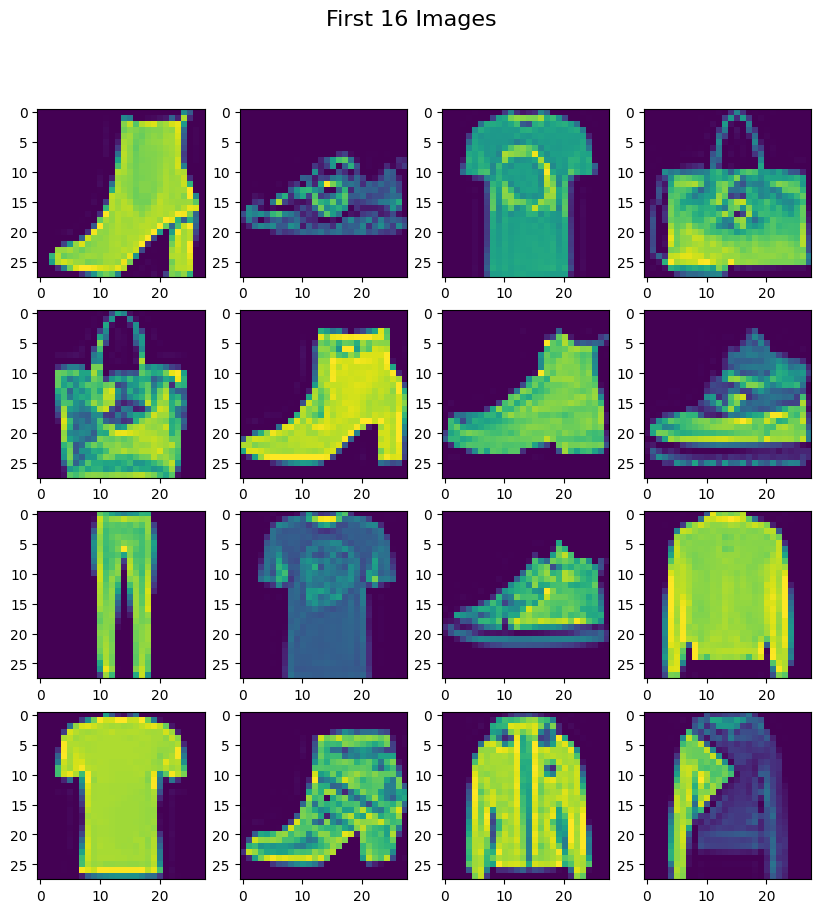

In [74]:
fig, axes = plt.subplots(4, 4, figsize=(10,10))
fig.suptitle("First 16 Images", fontsize=16)
for i, ax in enumerate(axes.flat):
    img = df.iloc[i, 1:].values.reshape(28, 28)
    ax.imshow(img)

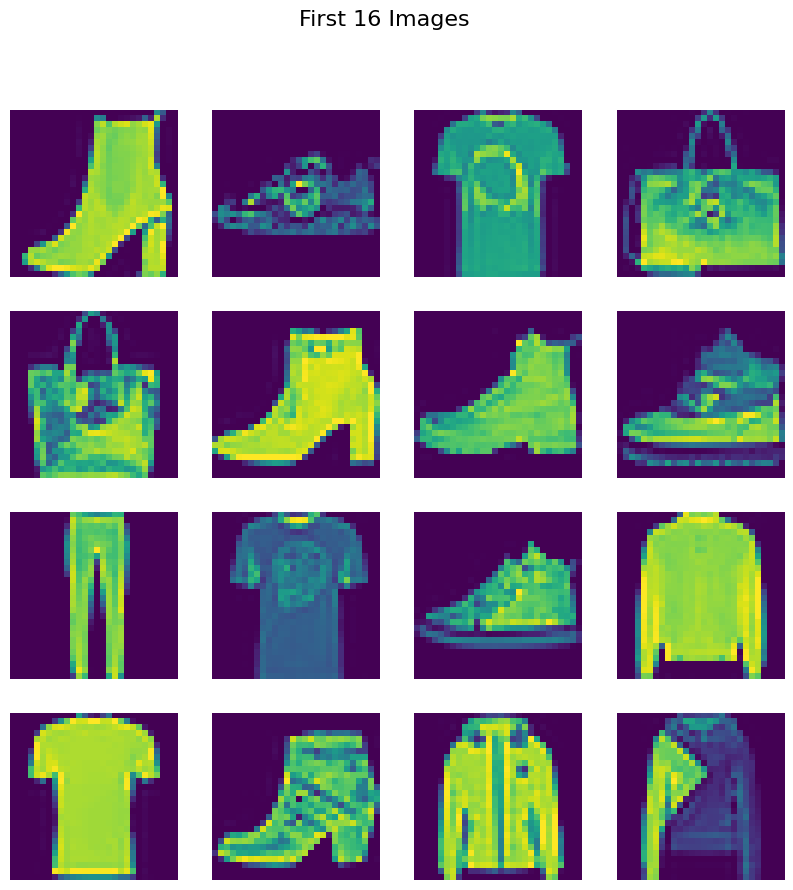

In [75]:
fig, axes = plt.subplots(4, 4, figsize=(10,10))
fig.suptitle("First 16 Images", fontsize=16)
for i, ax in enumerate(axes.flat):
    img = df.iloc[i, 1:].values.reshape(28, 28)
    ax.imshow(img)
    ax.axis('off')

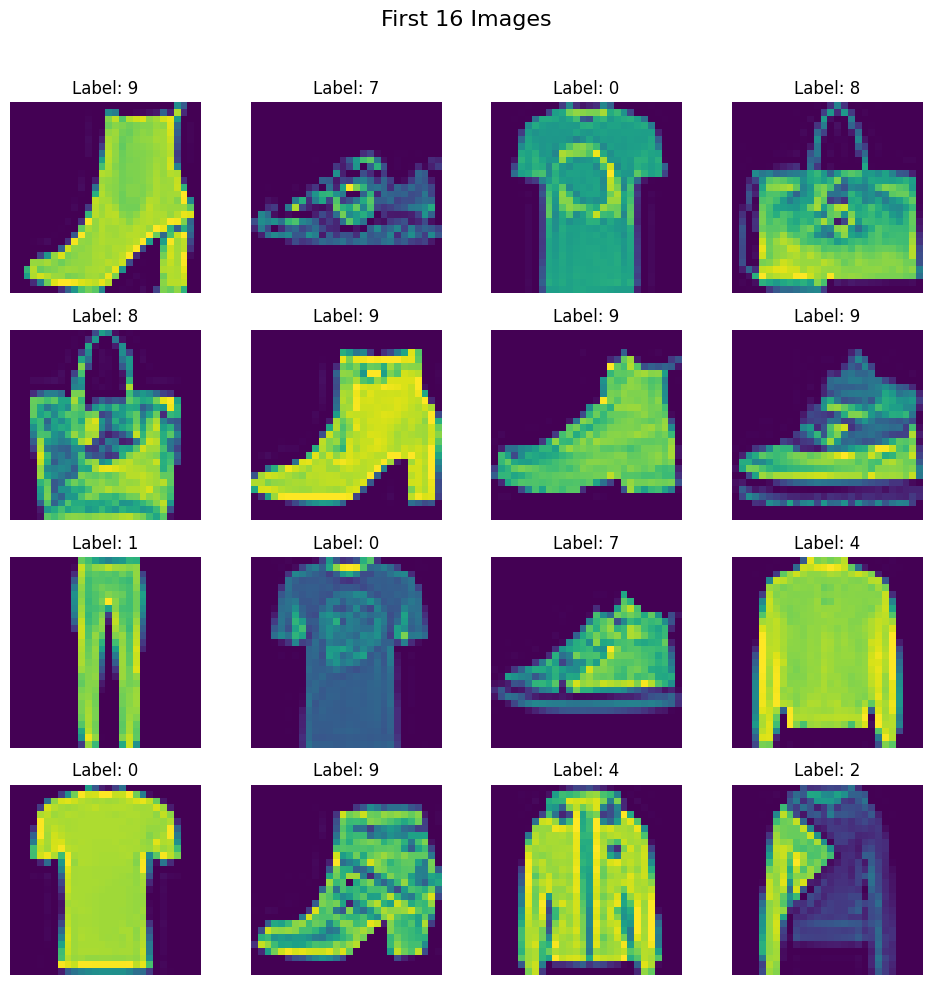

In [76]:
fig, axes = plt.subplots(4, 4, figsize=(10,10))
fig.suptitle("First 16 Images", fontsize=16)
for i, ax in enumerate(axes.flat):
    img = df.iloc[i, 1:].values.reshape(28, 28)
    ax.imshow(img)
    ax.axis('off')
    ax.set_title(f"Label: {df.iloc[i, 0]}")
    plt.tight_layout(rect=[0, 0, 1, 0.96])

In [77]:
df['label'].head(16)

0     9
1     7
2     0
3     8
4     8
5     9
6     9
7     9
8     1
9     0
10    7
11    4
12    0
13    9
14    4
15    2
Name: label, dtype: int64

In [78]:
X = df.iloc[:, 1:].values
y = df.iloc[:, 0].values

In [79]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.2, random_state=42
)

In [80]:
X_train.shape

(4800, 784)

In [81]:
X_train = X_train / 255.0
X_test = X_test / 255.0

In [82]:
class CustomDataset(Dataset):
    def __init__(self, features, labels):
        self.features = torch.tensor(features, dtype=torch.float32)
        self.labels = torch.tensor(labels, dtype=torch.long)
    
    def __len__(self):
        return len(self.features)
    
    def __getitem__(self, index):
        return self.features[index], self.labels[index]

In [83]:
train_dataset = CustomDataset(X_train, y_train)
test_dataset = CustomDataset(X_test, y_test)

In [84]:
train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    pin_memory=True
)

In [85]:
test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False,
    pin_memory=True
)

In [86]:
len(train_loader)

150

In [87]:
len(test_loader)

38

In [88]:
class MyNN(nn.Module):
    def __init__(self, num_features):
        super().__init__()
    
        self.model = nn.Sequential(
            nn.Linear(num_features, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64,10)
        )
    
    def forward(self, x):
        return self.model(x)

In [89]:
learning_rate = 0.1
epochs = 100

In [90]:
model = MyNN(X_train.shape[1])

In [91]:
model = model.to(device)

In [92]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=learning_rate)

In [93]:
for epoch in range(epochs):
    total_epoch_loss = 0

    for batch_features, batch_labels in train_loader:
        batch_features, batch_labels = batch_features.to(device), batch_labels.to(device)
        outputs = model(batch_features)
        loss = criterion(outputs, batch_labels)

        optimizer.zero_grad()
        loss.backward()

        optimizer.step()

        total_epoch_loss = total_epoch_loss + loss.item()
    
    avg_loss = total_epoch_loss / len(train_loader)
    print(f"Epoch: {epoch+1}, Loss: {avg_loss}")

c:\Users\HP\AppData\Local\Programs\Python\Python312\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch: 1, Loss: 1.3468754490216572
Epoch: 2, Loss: 0.8009187213579814
Epoch: 3, Loss: 0.6691517472267151
Epoch: 4, Loss: 0.6013209786017736
Epoch: 5, Loss: 0.5511612162987392
Epoch: 6, Loss: 0.5156959004203479
Epoch: 7, Loss: 0.4781132082144419
Epoch: 8, Loss: 0.44898557583491006
Epoch: 9, Loss: 0.4294230772058169
Epoch: 10, Loss: 0.4153449958562851
Epoch: 11, Loss: 0.38677300468087195
Epoch: 12, Loss: 0.38188349386056264
Epoch: 13, Loss: 0.34855827351411184
Epoch: 14, Loss: 0.3339748323957125
Epoch: 15, Loss: 0.32730279182394345
Epoch: 16, Loss: 0.3178599358101686
Epoch: 17, Loss: 0.31890534112850827
Epoch: 18, Loss: 0.29600761021176974
Epoch: 19, Loss: 0.2911862093458573
Epoch: 20, Loss: 0.2660218126078447
Epoch: 21, Loss: 0.26064893742402395
Epoch: 22, Loss: 0.26245415046811105
Epoch: 23, Loss: 0.25073150033752123
Epoch: 24, Loss: 0.23640245243906974
Epoch: 25, Loss: 0.2187945974121491
Epoch: 26, Loss: 0.2264356895784537
Epoch: 27, Loss: 0.20967572044581176
Epoch: 28, Loss: 0.221746

In [94]:
model.eval()

MyNN(
  (model): Sequential(
    (0): Linear(in_features=784, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=10, bias=True)
  )
)

In [95]:
total = 0
correct = 0

In [96]:
with torch.no_grad():
    for batch_features, batch_labels in test_loader:
        batch_features, batch_labels = batch_features.to(device), batch_labels.to(device)
        outputs = model(batch_features)

        _, predicted = torch.max(outputs, 1)
        total = total + batch_labels.shape[0]

        correct = correct + (predicted == batch_labels).sum().item()

print(correct/total)

0.845


In [97]:
with torch.no_grad():
    for batch_features, batch_labels in train_loader:
        batch_features, batch_labels = batch_features.to(device), batch_labels.to(device)
        outputs = model(batch_features)

        _, predicted = torch.max(outputs, 1)
        total = total + batch_labels.shape[0]

        correct = correct + (predicted == batch_labels).sum().item()

print(correct/total)

0.9676666666666667
